# Day 3: Microstructure Modeling (NODDI & DKI)

Welcome to the **Day 3 Interactive Microstructure Laboratory**.

In this notebook, we interactively explore:
0. **The AMICO gradient scheme file**: how `scil_NODDI_maps` turns `bval`/`bvec` into the format AMICO expects.
1. **Neurite Density Index (NDI / ICVF)**: Intra-cellular volume fraction (tight axonal packing in major white matter tracts).
2. **Orientation Dispersion Index (ODI)**: Angular dispersion of neurites (high in crossing/fanning regions, low in parallel bundles like the Corpus Callosum).
3. **Isotropic Volume Fraction (ISOVF, AMICO's `fit_FWF`)**: Free-water / CSF fraction (high in the ventricles).
4. **Mean Kurtosis (MK)**: Deviation from Gaussian diffusion sensitive to microstructural complexity and cellular packing.

In [5]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
%matplotlib inline

def find_file(filename):
    candidates = [filename, os.path.join("..", filename)]
    for path in candidates:
        if os.path.exists(path):
            return path
    return None

ndi_path = find_file("../NODDI_results/fit_NDI.nii.gz")
odi_path = find_file("../NODDI_results/fit_ODI.nii.gz")
isovf_path = find_file("../NODDI_results/fit_FWF.nii.gz")
fw_path = find_file("../fw.nii.gz") or find_file("../freewater_results/fit_FW.nii.gz")
mk_path = find_file("../dki_mk.nii.gz")
fa_path = find_file("../fa.nii.gz")

print(f"NDI file   : {ndi_path is not None}")
print(f"ODI file   : {odi_path is not None}")
print(f"ISOVF file : {isovf_path is not None}")
print(f"FW file    : {fw_path is not None}")
print(f"MK file    : {mk_path is not None}")
print(f"FA file    : {fa_path is not None}")

NDI file : True
ODI file : True
MK file  : True
FA file  : True


## 0. From `bval`/`bvec` to an AMICO scheme file

AMICO does not read FSL `bval`/`bvec` files directly: it needs a **scheme file**, one line per volume with `gx gy gz b`. `scil_NODDI_maps` (Tutorial 3.3) builds it for you internally; here we do it by hand with `amico.util.fsl2scheme`.

`bStep` snaps each b-value to the nearest shell. This matters for our data: six b0 volumes are stored as `b = 0.001`, and real scanners write e.g. `b = 995` or `b = 1005` for the nominal 1000 shell. On your own data, check the unique b-values below and pass your own shell list.

In [ ]:
import amico

bval_path = find_file("../bids_data/sub-01/ses-01/dwi/dwi.bval")
bvec_path = find_file("../bids_data/sub-01/ses-01/dwi/dwi.bvec")

if bval_path and bvec_path:
    print("Unique b-values in the bval file:", np.unique(np.loadtxt(bval_path)))
    scheme_path = "../dwi_amico.scheme"
    amico.util.fsl2scheme(bval_path, bvec_path, schemeFilename=scheme_path,
                          bStep=[0, 300, 1000, 2000])
    scheme = np.loadtxt(scheme_path, skiprows=1)  # first line is the 'VERSION: BVECTOR' header
    print(f"Scheme: {scheme.shape[0]} volumes x {scheme.shape[1]} columns (gx gy gz b)")
    print("Unique b-values in the scheme  :", np.unique(scheme[:, 3]))
    print(open(scheme_path).read().splitlines()[:4])
else:
    print("bval/bvec not found yet. Please run tutorial_1.0_setup_data.sh first.")

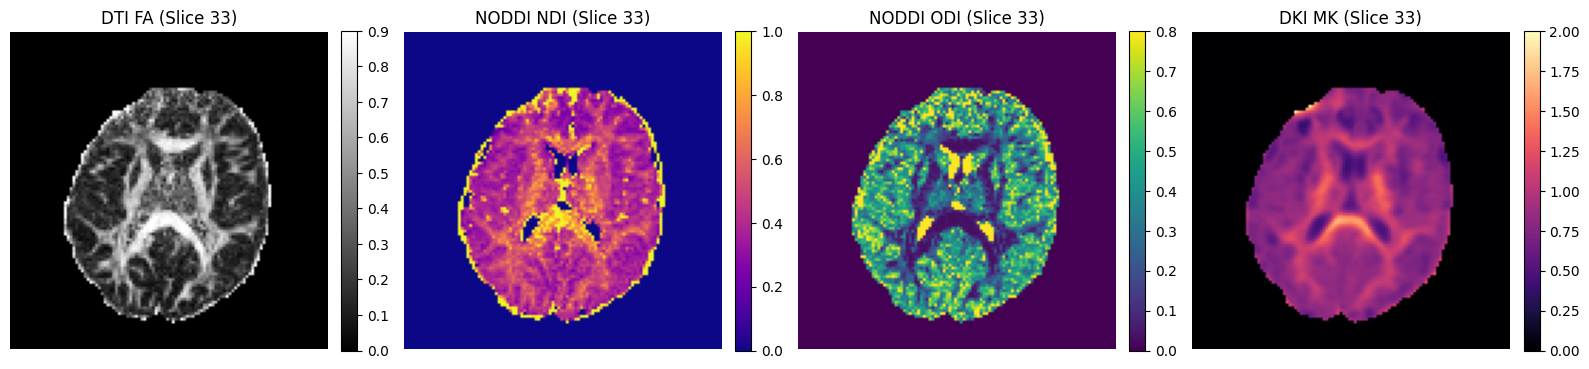

In [6]:
if ndi_path and os.path.exists(ndi_path):
    ndi_data = nib.load(ndi_path).get_fdata()
    odi_data = nib.load(odi_path).get_fdata() if odi_path and os.path.exists(odi_path) else None
    isovf_data = nib.load(isovf_path).get_fdata() if isovf_path and os.path.exists(isovf_path) else None
    fw_data = nib.load(fw_path).get_fdata() if fw_path and os.path.exists(fw_path) else None
    mk_data = nib.load(mk_path).get_fdata() if mk_path and os.path.exists(mk_path) else None
    fa_data = nib.load(fa_path).get_fdata() if fa_path and os.path.exists(fa_path) else None

    slice_z = ndi_data.shape[2] // 2

    n_plots = 1 + (odi_data is not None) + (isovf_data is not None) + (fw_data is not None) + (mk_data is not None) + (fa_data is not None)
    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4))
    if n_plots == 1:
        axes = [axes]
    
    idx = 0
    # 1. FA
    if fa_data is not None:
        im0 = axes[idx].imshow(np.rot90(fa_data[:, :, slice_z]), cmap="gray", vmin=0, vmax=0.9)
        axes[idx].set_title(f"DTI FA (Slice {slice_z})")
        axes[idx].axis("off")
        plt.colorbar(im0, ax=axes[idx], fraction=0.046, pad=0.04)
        idx += 1
    
    # 2. NDI
    im1 = axes[idx].imshow(np.rot90(ndi_data[:, :, slice_z]), cmap="plasma", vmin=0, vmax=1.0)
    axes[idx].set_title(f"NODDI NDI (Slice {slice_z})")
    axes[idx].axis("off")
    plt.colorbar(im1, ax=axes[idx], fraction=0.046, pad=0.04)
    idx += 1

    # 3. ODI
    if odi_data is not None:
        im2 = axes[idx].imshow(np.rot90(odi_data[:, :, slice_z]), cmap="viridis", vmin=0, vmax=0.8)
        axes[idx].set_title(f"NODDI ODI (Slice {slice_z})")
        axes[idx].axis("off")
        plt.colorbar(im2, ax=axes[idx], fraction=0.046, pad=0.04)
        idx += 1

    # 4. ISOVF (AMICO fit_FWF)
    if isovf_data is not None:
        im4 = axes[idx].imshow(np.rot90(isovf_data[:, :, slice_z]), cmap="cividis", vmin=0, vmax=1.0)
        axes[idx].set_title(f"NODDI ISOVF (Slice {slice_z})")
        axes[idx].axis("off")
        plt.colorbar(im4, ax=axes[idx], fraction=0.046, pad=0.04)
        idx += 1

    # 5. Free Water (AMICO fit_FW)
    if fw_data is not None:
        im5 = axes[idx].imshow(np.rot90(fw_data[:, :, slice_z]), cmap="Blues_r", vmin=0, vmax=1.0)
        axes[idx].set_title(f"Free Water FW (Slice {slice_z})")
        axes[idx].axis("off")
        plt.colorbar(im5, ax=axes[idx], fraction=0.046, pad=0.04)
        idx += 1

    # 6. MK
    if mk_data is not None:
        im3 = axes[idx].imshow(np.rot90(mk_data[:, :, slice_z]), cmap="magma", vmin=0, vmax=2.0)
        axes[idx].set_title(f"DKI MK (Slice {slice_z})")
        axes[idx].axis("off")
        plt.colorbar(im3, ax=axes[idx], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
else:
    print("Microstructure parameter maps not found yet. Please run tutorial_3.3_microstructure_our_data.sh first.")